# Combinatorial perturbations: CRISPRa gene pairs (Norman)

This tutorial covers cells that receive one or two perturbations, without experimental
conditions. It applies SHERLOCK to the combinatorial CRISPRa screen of Norman et al. (2019), which
activated 105 single genes and 131 gene pairs in K562 cells. It covers:

1. **Preparing** a dataset whose labels include gene pairs (`A+B`).
2. **Holding out** a set of pairs so the model never sees their cells.
3. **Training** SHERLOCK in combinatorial mode (or loading a pretrained checkpoint).
4. **Predicting** the effects of seen and held-out pairs counterfactually.
5. **Classifying genetic interactions** (additive, synergy, suppression, ...) from the model's
   effect vectors, and comparing them with the labels annotated by Norman et al.

**How SHERLOCK models a pair.** A combination does not get its own embedding. Its latent shift
is built from its two parents,

$$\Delta_{A+B} = c_A\,\Delta_A + c_B\,\Delta_B + s(\rho_A, \rho_B),$$

where $c_A, c_B \in (0, 2)$ rescale each parent's shift and $s$ is a learned interaction term.
Training starts from the additive model ($c_A = c_B = 1$, $s = 0$) and penalizes departures
from it, so non-additivity is learned only when the data support it. Because a pair reuses its
parents' parameters, SHERLOCK can also predict pairs that were never observed.

## 1. Setup

In [1]:
import math
import os
import random

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score, f1_score,
                             roc_auc_score)

import sherlock as slk   # pip install sherlock-perturb

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2. Load and prepare the data

`slk.datasets.norman()` downloads the dataset (about 1.7 GB) to `~/.cache/sherlock` on first use;
pass `path=` to read a local copy instead. It is the labelled version of the Norman et al. data
([Figshare](https://figshare.com/articles/dataset/Norman_et_al_2019_Science_labeled_Perturb-seq_data/24688110?file=43390776)).
The loader puts the raw counts in `.X` and maps the perturbation labels (pairs written as `A+B`,
controls as `control`) onto SHERLOCK's standard keys.

In [2]:
slk.configs.reset_config()
data = slk.datasets.norman()
P_KEY = slk.configs.get_config("pert_key")
NTC   = slk.configs.get_config("ntc_label")

labels = data.obs[P_KEY].astype(str)
singles = sorted({p for p in labels.unique() if "+" not in p and p != NTC})
pairs   = sorted({p for p in labels.unique() if "+" in p})
print(f"{data.n_obs:,} cells | {len(singles)} single perturbations | {len(pairs)} pairs")

111,255 cells | 105 single perturbations | 131 pairs


We keep genes with a mean above 0.5 UMI per cell, plus every activated gene so each perturbation's
own target can be read out even when it is lowly expressed. Observed average treatment effects
(ATEs) are then computed against the control cells.

In [3]:
targets = {g for p in labels.unique() if p != NTC for g in p.split("+")}
mean_expr = np.asarray(data.X.mean(axis=0)).ravel()
data = data[:, (mean_expr > 0.5) | data.var_names.isin(targets)].copy()
print(f"Kept {data.n_vars:,} genes")

slk.pp.treat_effect(data, label_col=P_KEY, control_label=NTC, method="perturbseq",
                    inplace=True, key="treat_effect")

Kept 3,270 genes


## 3. Genetic-interaction labels and held-out pairs

Norman et al. annotated 88 pairs with one of eight interaction classes. We merge the two synergy
subtypes into a single class, and hold out 20% of the labelled pairs (stratified by class). All
cells carrying a held-out pair are removed from training; their two single perturbations are kept,
so the model has to predict each held-out pair from its parents alone.

In [4]:
def canon(p):
    # Order-independent pair name: A+B and B+A are the same combination.
    return "+".join(sorted(str(p).split("+")))

gi = pd.read_csv("data/norman_genetic_interactions.csv")
gi["combination"] = gi["combination"].map(canon)
gi["genetic_interaction"] = gi["genetic_interaction"].str.strip()
gi_series = gi.set_index("combination")["genetic_interaction"]

random.seed(42)
held_out = set()
for cls, grp in gi.groupby("genetic_interaction"):
    held_out.update(random.sample(list(grp["combination"]), math.ceil(0.2 * len(grp))))

is_held = data.obs[P_KEY].map(lambda p: "+" in str(p) and canon(p) in held_out).astype(bool)
data_train = data[~is_held].copy()
print(f"Labelled pairs: {len(gi)} | held out: {len(held_out)} | training cells: {data_train.n_obs:,}")
gi["genetic_interaction"].value_counts().to_frame("pairs")

Labelled pairs: 88 | held out: 22 | training cells: 104,626


,pairs
genetic_interaction,
approximately additive,16
neomorphic,13
synergy (dissimilar phenotype),13
suppression,12
synergy (similar phenotype),11
epistasis,9
redundant,8
potentiation,6


## 4. Train SHERLOCK in combinatorial mode

`combinatorial=True` splits each `A+B` label into its two parents, and `synergy=True` enables the
interaction term $s$. The remaining settings are those used in the manuscript:

| argument | value | role |
|---|---|---|
| `latent_dim` | 16 | size of the latent cell state |
| `rank` | 16 | rank of the perturbation covariance $\Sigma_P$ |
| `synergy_rank` | 6 | width of the interaction network $s$ |
| `l0_lambda`, `n_epochs_l0_warmup` | 0.1, 300 | gate sparsity and its warm-up |
| `num_epochs`, `patience`, `validate_every` | 500, 30, 50 | training length and early stopping |

Training takes about 30 minutes on a GPU. The checkpoint loaded below is run 1 of the five runs
reported in the manuscript; set `RETRAIN = True` to train your own.

In [5]:
CHECKPOINT = "../../results/tutorials/norman_combinatorial.pth"
RETRAIN = False

if not RETRAIN and os.path.exists(CHECKPOINT):
    model = slk.tl.load_results(CHECKPOINT).to(DEVICE)
    print(f"Loaded {CHECKPOINT}")
else:
    out = slk.tl.run(
        data_train, model="vae", combinatorial=True, synergy=True,
        latent_dim=16, rank=16, synergy_rank=6,
        l0_lambda=1e-1, n_epochs_l0_warmup=300,
        num_epochs=500, validate_every=50, patience=30,
        seed=0, device=DEVICE,
    )
    slk.tl.save_results(out, CHECKPOINT)
    model = out["model"]

Loaded ../../results/tutorials/norman_combinatorial.pth


## 5. Latent space

`slk.tl.eval` encodes every cell. Pairs are placed relative to their parents, often between them.

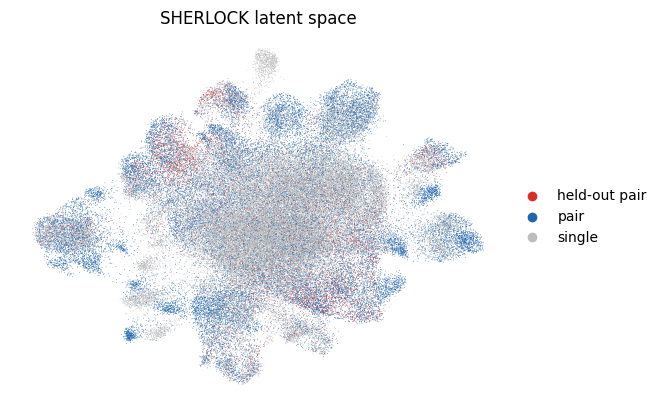

In [6]:
slk.tl.eval(model, data, obsm_key="z", uns_key="results", device=DEVICE)

sub = data[data.obs[P_KEY] != NTC].copy()
sub.obs["type"] = np.where(sub.obs[P_KEY].str.contains(r"\+"), "pair", "single")
sub.obs.loc[sub.obs[P_KEY].map(lambda p: canon(p) in held_out).values, "type"] = "held-out pair"
sc.pp.neighbors(sub, use_rep="z", random_state=0)
sc.tl.umap(sub, random_state=0)
sc.pl.umap(sub, color="type", palette={"single": "#bdbdbd", "pair": "#2166ac", "held-out pair": "#d73027"},
           frameon=False, title="SHERLOCK latent space")

## 6. Counterfactual effects of seen and held-out pairs

For each perturbation, SHERLOCK takes the control cells' latent states, applies that perturbation's
shift (for a pair, the composed shift above) and decodes. We compare the predicted effects with the
observed ATEs separately for single perturbations, pairs seen in training and held-out pairs.

In [7]:
cf = model.predict_counterfactual_effects(
    data, observed_effect=data.uns["treat_effect"], approximate=False, device=DEVICE)
pred, obs = cf["predicted_df"], cf["observed_df"]

def ate_r(index):
    index = [p for p in index if p in pred.index]
    return pearsonr(pred.loc[index].values.ravel(), obs.loc[index].values.ravel())[0]

groups = {
    "all": list(pred.index),
    "singles": [p for p in pred.index if "+" not in p],
    "seen pairs": [p for p in pred.index if "+" in p and canon(p) not in held_out],
    "held-out pairs": [p for p in pred.index if "+" in p and canon(p) in held_out],
}
pd.Series({k: ate_r(v) for k, v in groups.items()}).round(3).to_frame("Pearson r")

,Pearson r
all,0.855
singles,0.827
seen pairs,0.874
held-out pairs,0.829


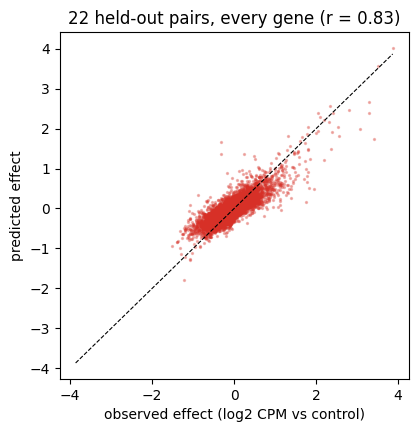

In [8]:
held = groups["held-out pairs"]
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(obs.loc[held].values.ravel(), pred.loc[held].values.ravel(), s=2, alpha=0.3, color="#d73027")
lim = np.abs(obs.loc[held].values).max()
ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8)
ax.set(xlabel="observed effect (log2 CPM vs control)", ylabel="predicted effect",
       title=f"{len(held)} held-out pairs, every gene (r = {ate_r(held):.2f})")
plt.show()

## 7. Genetic-interaction classification

For every pair, `model.get_gi` builds three effect vectors in gene space (one per parent and one
for the pair), regresses the pair on its parents as Norman et al. did, and derives eleven metrics
such as dominance, the additive residual and the similarity of the parents.
`slk.tl.classify_gi` turns those metrics into one of seven classes with fixed composite scores; no
labels are used.

With `mode="observed"`, all three vectors are decoded from the cells that received each
perturbation, so this measures how well the fitted model preserves the interaction structure of
the data.

In [9]:
gi_obs = model.get_gi(data, min_cells=5, mode="observed")
gi_obs.index = (gi_obs["pert_a"].astype(str) + "+" + gi_obs["pert_b"].astype(str)).map(canon)
gi_obs = slk.tl.classify_gi(gi_obs, inplace=True)
gi_obs[["pert_a", "pert_b", "magnitude", "dominance", "singles_similarity",
        "norm_ab_over_additive", "predicted_gi"]].head()

regress_gi_params:   0%|          | 0/131 [00:00<?, ?pair/s]

,pert_a,pert_b,magnitude,dominance,singles_similarity,norm_ab_over_additive,predicted_gi
AHR+FEV,AHR,FEV,1.745990,0.280469,0.549465,1.132641,potentiation
AHR+KLF1,AHR,KLF1,1.180650,0.547313,0.201606,0.836054,epistasis
BAK1+BCL2L11,BAK1,BCL2L11,1.168073,0.891670,0.182023,1.152374,neomorphic
BAK1+KLF1,BAK1,KLF1,1.005493,0.648388,0.264727,0.958001,epistasis
BAK1+TMSB4X,BAK1,TMSB4X,1.026719,0.371216,0.192918,0.876363,epistasis


,all labelled pairs
pairs,86.000
weighted F1,0.727
ARI,0.457
AMI,0.529


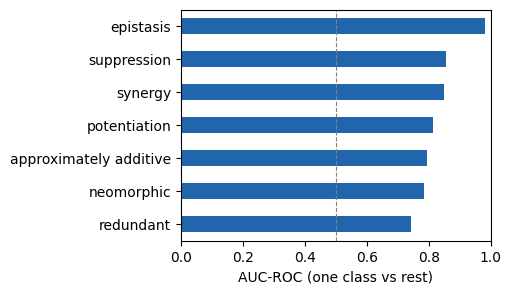

In [10]:
MERGE = {"synergy (similar phenotype)": "synergy", "synergy (dissimilar phenotype)": "synergy"}

def evaluate(gi_df, pairs=None):
    df = gi_df[gi_df.index.isin(gi_series.index) & gi_df["predicted_gi"].notna()]
    if pairs is not None:
        df = df[df.index.isin(pairs)]
    y_true = df.index.map(gi_series).astype(str).to_series().replace(MERGE).values
    y_pred = df["predicted_gi"].astype(str).replace(MERGE).values
    per_class = {c: roc_auc_score(y_true == c, y_pred == c) for c in sorted(set(y_true))
                 if 0 < (y_true == c).sum() < len(y_true)}
    summary = {"pairs": len(df), "weighted F1": f1_score(y_true, y_pred, average="weighted"),
               "ARI": adjusted_rand_score(y_true, y_pred), "AMI": adjusted_mutual_info_score(y_true, y_pred)}
    return pd.Series(summary).round(3), pd.Series(per_class, name="AUC-ROC").round(3)

summary, per_class = evaluate(gi_obs)
display(summary.to_frame("all labelled pairs"))
per_class.sort_values().plot.barh(color="#2166ac", figsize=(4, 3), xlim=(0, 1))
plt.axvline(0.5, color="grey", ls="--", lw=0.8)
plt.xlabel("AUC-ROC (one class vs rest)")
plt.show()

### Held-out pairs

A held-out pair has no training cells, so its effect is generated from the composed shift while
the parents are decoded from their own cells (`mode="hybrid"`). The pair is then scored exactly as
above.

In [11]:
gi_held = model.get_gi(data, min_cells=5, mode="hybrid")
gi_held.index = (gi_held["pert_a"].astype(str) + "+" + gi_held["pert_b"].astype(str)).map(canon)
gi_held = slk.tl.classify_gi(gi_held, inplace=True)
summary_held, _ = evaluate(gi_held, pairs=held_out)
summary_held.to_frame("held-out pairs")

regress_gi_params:   0%|          | 0/131 [00:00<?, ?pair/s]

,held-out pairs
pairs,22.000
weighted F1,0.647
ARI,0.390
AMI,0.415


### One example per class

The table lists, for each annotated class, a pair the model classifies correctly, with the
observed metrics that drive the call.

In [12]:
lab = gi_obs[gi_obs.index.isin(gi_series.index)].copy()
lab["label"] = lab.index.map(gi_series).to_series().replace(MERGE).values
lab["predicted"] = lab["predicted_gi"].replace(MERGE)
correct = lab[lab["label"] == lab["predicted"]]
correct.groupby("label").head(1)[["label", "magnitude", "dominance", "singles_similarity",
                                  "norm_ab_over_additive", "additive_residual_norm"]].round(2)

,label,magnitude,dominance,singles_similarity,norm_ab_over_additive,additive_residual_norm
AHR+KLF1,epistasis,1.18,0.55,0.20,0.84,0.53
BPGM+SAMD1,approximately additive,1.30,0.27,0.69,0.81,0.24
CBFA2T3+FEV,potentiation,2.56,0.05,0.18,1.87,0.99
CBFA2T3+POU3F2,synergy,1.67,0.34,0.64,1.18,0.39
CBL+UBASH3A,neomorphic,1.47,0.10,0.79,1.23,0.69
CDKN1A+CDKN1C,redundant,1.01,0.47,0.98,0.64,0.37
CEBPB+PTPN12,suppression,0.81,0.06,0.43,0.54,0.48


## Next steps

- The manuscript compares these scores with GEARS and with measured expression, and relates the
  interaction classes to consensus perturbation modules along an erythroid axis. That code is in
  [SHERLOCK_Reproducibility](https://github.com/azizilab/SHERLOCK_Reproducibility).
- `slk.tl.regress_gi_params` applies the same scoring to effect vectors from any source, for
  example another model's predictions.
- For single perturbations, see the [single-perturbation tutorial](single_perturbations.ipynb); for perturbations measured under several
  conditions, see the [conditional-perturbation tutorial](conditional_perturbations.ipynb).

## References

1. Zhang M, Myers JD, Shi L, Giglio RM, Chatterjee S, McFaline-Figueroa JL, Azizi E. SHERLOCK: Structured representation learning and causal inference of downstream perturbation effects. *bioRxiv* (2026). [doi:10.64898/2026.09.25.754573](https://www.biorxiv.org/content/10.64898/2026.09.25.754573v1)
2. Norman TM *et al.* Exploring genetic interaction manifolds constructed from rich single-cell phenotypes. *Science* **365**, 786–793 (2019). [doi:10.1126/science.aax4438](https://doi.org/10.1126/science.aax4438)